In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Load the data
data_titles = pd.read_csv('../data/data_cleaned_titles.csv')
clusters = pd.read_csv('../data/predictions.csv')

# Merge on id
data = pd.merge(data_titles, clusters, on='id', how='left')

# Combine title and tags
data['text'] = data['title'].fillna('') + ' ' + data['tags'].fillna('')

def get_top_clusters(data, cluster_col, n_clusters=30):
    # Compte le nombre de points par cluster
    cluster_counts = (
        data[data[cluster_col].notna() & (data[cluster_col] != -1)]
        .groupby(cluster_col)
        .size()
        .sort_values(ascending=False)
    )
    return cluster_counts.head(n_clusters).index.tolist()

def get_all_clusters(data, cluster_col):
    # Compte le nombre de points par cluster
    cluster_counts = (
        data[data[cluster_col].notna() & (data[cluster_col] != -1)]
        .groupby(cluster_col)
        .size()
        .sort_values(ascending=False)
    )
    return cluster_counts.index.tolist()

def get_top_words_per_cluster(data, cluster_col, selected_clusters):
    grouped = data.groupby(cluster_col)
    
    documents = []
    cluster_labels = []
    
    for cluster, group in grouped:
        if cluster not in selected_clusters:
            continue
        text = ' '.join(group['text'])
        documents.append(text)
        cluster_labels.append(cluster)

    if not documents:
        return {}

    vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
    tfidf_matrix = vectorizer.fit_transform(documents)
    feature_names = vectorizer.get_feature_names_out()

    top_words = {}
    for i, cluster in enumerate(cluster_labels):
        scores = tfidf_matrix[i].toarray().flatten()
        top_indices = scores.argsort()[-10:][::-1]
        top_words[cluster] = [(feature_names[idx], scores[idx]) for idx in top_indices]

    return top_words

def get_word_frequencies_for_cluster(data, cluster_col, selected_clusters):
    grouped = data.groupby(cluster_col)
    word_freqs = {}

    for cluster, group in grouped:
        if cluster not in selected_clusters:
            continue

        text = ' '.join(group['text'])
        if not text.strip():
            word_freqs[cluster] = {}
            continue

        try:
            vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
            tfidf_matrix = vectorizer.fit_transform([text])
            feature_names = vectorizer.get_feature_names_out()
            scores = tfidf_matrix.toarray().flatten()
            word_freqs[cluster] = {
                feature_names[i]: scores[i]
                for i in range(len(feature_names)) if scores[i] > 0
            }
        except ValueError:
            word_freqs[cluster] = {}

    return word_freqs

clustering_methods = ['hdbscan','dbscan','kmean','isolation_forest']
"""
for method in clustering_methods:
    print(f"\n===== {method.upper()} =====")

    # Sélection des 30 plus gros clusters
    top_clusters = get_top_clusters(data, method, n_clusters=30)

    if not top_clusters:
        print("No clusters found.")
        continue

    top_words = get_top_words_per_cluster(data, method, top_clusters)
    word_freqs = get_word_frequencies_for_cluster(data, method, top_clusters)

    for cluster in top_clusters:
        if cluster not in top_words:
            continue

        print(f"\nCluster {cluster} — {len(data[data[method] == cluster])} photos")
        print(top_words[cluster])

        if cluster in word_freqs and word_freqs[cluster]:
            wordcloud = WordCloud(
                width=800,
                height=400,
                background_color='white'
            ).generate_from_frequencies(word_freqs[cluster])

            img = wordcloud.to_image()      # PIL Image
            plt.figure(figsize=(10, 5))
            plt.imshow(np.array(img))       # conversion explicite SANS copy
            plt.axis('off')
            plt.title(f'Word Cloud for {method} Cluster {cluster}')
            plt.show()


"""

C:\Users\jhony\AppData\Local\Temp\ipykernel_26472\1146999039.py:8: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  data_titles = pd.read_csv('../data/data_cleaned_titles.csv')


'\nfor method in clustering_methods:\n    print(f"\n===== {method.upper()} =====")\n\n    # Sélection des 30 plus gros clusters\n    top_clusters = get_top_clusters(data, method, n_clusters=30)\n\n    if not top_clusters:\n        print("No clusters found.")\n        continue\n\n    top_words = get_top_words_per_cluster(data, method, top_clusters)\n    word_freqs = get_word_frequencies_for_cluster(data, method, top_clusters)\n\n    for cluster in top_clusters:\n        if cluster not in top_words:\n            continue\n\n        print(f"\nCluster {cluster} — {len(data[data[method] == cluster])} photos")\n        print(top_words[cluster])\n\n        if cluster in word_freqs and word_freqs[cluster]:\n            wordcloud = WordCloud(\n                width=800,\n                height=400,\n                background_color=\'white\'\n            ).generate_from_frequencies(word_freqs[cluster])\n\n            img = wordcloud.to_image()      # PIL Image\n            plt.figure(figsize=(1

In [ ]:
# Save top 10 words for each cluster (all clusters) to CSV
for method in clustering_methods:
    # Prepare a DataFrame to store results
    results = []
    print(f"Processing method: {method}")
    all_clusters = get_all_clusters(data, method)
    if not all_clusters:
        continue
    top_words = get_top_words_per_cluster(data, method, all_clusters)
    for cluster in all_clusters:
        if cluster not in top_words:
            continue
        words = [word for word, _ in top_words[cluster]]
        results.append({
            'cluster': cluster,
            'words': ' '.join(words),
        })

    # Convert to DataFrame and save
    results_df = pd.DataFrame(results)
    results_df.to_csv(f'../data/cluster_descriptions_{method}.csv', index=False)
    print(f"Saved top 10 words for each cluster to ../data/cluster_descriptions_{method}.csv")

In [2]:
import matplotlib.dates as mdates
from datetime import datetime
import seaborn as sns

print("TEMPORAL ANALYSIS OF CLUSTERS")

# Create a date column from the taken dates
data['date_taken'] = pd.to_datetime(
    data[['date_taken_year', 'date_taken_month', 'date_taken_day']].rename(
        columns={
            'date_taken_year': 'year',
            'date_taken_month': 'month',
            'date_taken_day': 'day'
        }
    ),
    errors='coerce'
)

clustering_methods = ['hdbscan', 'dbscan', 'kmean', 'isolation_forest']

for method in clustering_methods:
    print(f"\n\n{'=' * 80}")
    print(f"METHOD: {method.upper()}")
    print(f"{'=' * 80}")
    
    # Get top clusters
    top_clusters = get_top_clusters(data, method, n_clusters=30)
    
    if not top_clusters:
        continue
    
    temporal_analysis = {}
    
    for cluster in top_clusters:
        cluster_data = data[data[method] == cluster].copy()
        cluster_data = cluster_data[cluster_data['date_taken'].notna()]
        
        if len(cluster_data) == 0:
            continue
        
        # ===== 1. TEMPORAL SPREAD ANALYSIS =====
        min_date = cluster_data['date_taken'].min()
        max_date = cluster_data['date_taken'].max()
        date_range = (max_date - min_date).days
        years_span = max_date.year - min_date.year + 1
        
        # Concentration analysis
        yearly_counts = cluster_data.groupby(cluster_data['date_taken'].dt.year).size()
        peak_year_count = yearly_counts.max()
        total_photos = len(cluster_data)
        concentration = (peak_year_count / total_photos) * 100
        
        # ===== 2. RECURRING PATTERN DETECTION =====
        # Create (month, day) tuples ignoring year
        cluster_data['month_day'] = cluster_data['date_taken'].dt.strftime('%m-%d')
        month_day_counts = cluster_data['month_day'].value_counts()
        unique_dates_per_year = cluster_data.groupby(cluster_data['date_taken'].dt.year)['month_day'].nunique()
        
        # Check for recurring dates across years
        recurring_dates = {}
        for md, count in month_day_counts.items():
            year_appearances = cluster_data[cluster_data['month_day'] == md]['date_taken'].dt.year.nunique()
            if year_appearances > 1:
                recurring_dates[md] = {'count': count, 'years': year_appearances}
        
        # ===== 3. TEMPORAL METRICS =====
        unique_years = cluster_data['date_taken'].dt.year.nunique()
        unique_months = cluster_data['date_taken'].dt.month.nunique()
        
        # Seasonality index (concentration in specific months)
        monthly_counts = cluster_data.groupby(cluster_data['date_taken'].dt.month).size()
        peak_month_count = monthly_counts.max()
        seasonality = (peak_month_count / total_photos) * 100
        
        # Time gaps
        sorted_dates = cluster_data['date_taken'].sort_values()
        if len(sorted_dates) > 1:
            date_diffs = sorted_dates.diff().dt.days
            max_gap = date_diffs.max()
            avg_gap = date_diffs.mean()
        else:
            max_gap = 0
            avg_gap = 0
        
        # ===== 5. CLASSIFICATION =====
        if date_range < 61:  # Less than 2 months
            event_type = "ONE-TIME EVENT"
        elif len(recurring_dates) > 0 and unique_years >= 2:
            event_type = "RECURRING EVENT"
        else:
            event_type = "PERSISTENT LOCATION"
        
        # Store analysis
        temporal_analysis[cluster] = {
            'event_type': event_type,
            'total_photos': total_photos,
            'min_date': min_date,
            'max_date': max_date,
            'date_range_days': date_range,
            'years_span': years_span,
            'unique_years': unique_years,
            'unique_months': unique_months,
            'concentration': concentration,
            'seasonality': seasonality,
            'max_gap_days': max_gap,
            'avg_gap_days': avg_gap,
            'recurring_dates_count': len(recurring_dates),
            'recurring_dates': recurring_dates
        }
    
    # ===== PRINT RESULTS =====
    print(f"\n{'CLUSTER':<8} {'TYPE':<20} {'PHOTOS':<10} {'YEARS':<8} {'SPAN (DAYS)':<15} {'RECURRING':<10}")
    print("-" * 80)
    
    for cluster in sorted(temporal_analysis.keys()):
        analysis = temporal_analysis[cluster]
        print(f"{cluster:<8} {analysis['event_type']:<20} {analysis['total_photos']:<10} "
              f"{analysis['unique_years']:<8} {analysis['date_range_days']:<15} {analysis['recurring_dates_count']:<10}")
    
    # ===== DETAILED ANALYSIS FOR EACH CLUSTER =====
    print(f"\n\n{'DETAILED ANALYSIS:':-^80}")
    
    for cluster in sorted(temporal_analysis.keys()):
        analysis = temporal_analysis[cluster]
        print(f"\n{'CLUSTER ' + str(cluster) + ':':-^80}")
        print(f"  Event Type: {analysis['event_type']}")
        print(f"  Total Photos: {analysis['total_photos']}")
        print(f"  Date Range: {analysis['min_date'].date()} to {analysis['max_date'].date()}")
        print(f"  Temporal Span: {analysis['years_span']} years, {analysis['date_range_days']} days")
        print(f"  Unique Years: {analysis['unique_years']}")
        print(f"  Unique Months: {analysis['unique_months']}")
        print(f"  Peak Year Concentration: {analysis['concentration']:.2f}%")
        print(f"  Seasonality (Peak Month): {analysis['seasonality']:.2f}%")
        print(f"  Max Gap Between Photos: {analysis['max_gap_days']:.0f} days")
        print(f"  Avg Gap Between Photos: {analysis['avg_gap_days']:.0f} days")
        print(f"  Recurring Dates (across years): {analysis['recurring_dates_count']}")
        
        if analysis['recurring_dates']:
            print(f"    Top recurring dates:")
            for md, info in sorted(analysis['recurring_dates'].items(), 
                                   key=lambda x: x[1]['years'], reverse=True)[:5]:
                print(f"      {md}: {info['years']} years, {info['count']} photos")

print(f"\n\n{'SUMMARY:':-^80}")
for method in clustering_methods:
    print(f"\n{method.upper()}:")
    top_clusters = get_top_clusters(data, method, n_clusters=30)
    cluster_data = data[data[method].isin(top_clusters)].copy()
    cluster_data = cluster_data[cluster_data['date_taken'].notna()]
    
    # Quick summary by type
    if len(cluster_data) > 0:
        print(f"  Total clusters analyzed: {len(top_clusters)}")
        print(f"  Date coverage: {cluster_data['date_taken'].min().year} to {cluster_data['date_taken'].max().year}")


TEMPORAL ANALYSIS OF CLUSTERS


METHOD: HDBSCAN

CLUSTER  TYPE                 PHOTOS     YEARS    SPAN (DAYS)     RECURRING 
--------------------------------------------------------------------------------
20.0     RECURRING EVENT      923        10       3870            1         
25.0     PERSISTENT LOCATION  465        4        1726            0         
58.0     PERSISTENT LOCATION  295        6        2950            0         
77.0     PERSISTENT LOCATION  717        2        97              0         
79.0     PERSISTENT LOCATION  583        2        564             0         
94.0     PERSISTENT LOCATION  742        3        592             0         
99.0     PERSISTENT LOCATION  399        3        814             0         
116.0    PERSISTENT LOCATION  624        3        1398            0         
118.0    PERSISTENT LOCATION  555        3        866             0         
131.0    RECURRING EVENT      430        7        3395            15        
139.0    RECURRING EVEN



GENERATING VISUALIZATIONS

Generating visualizations for HDBSCAN...


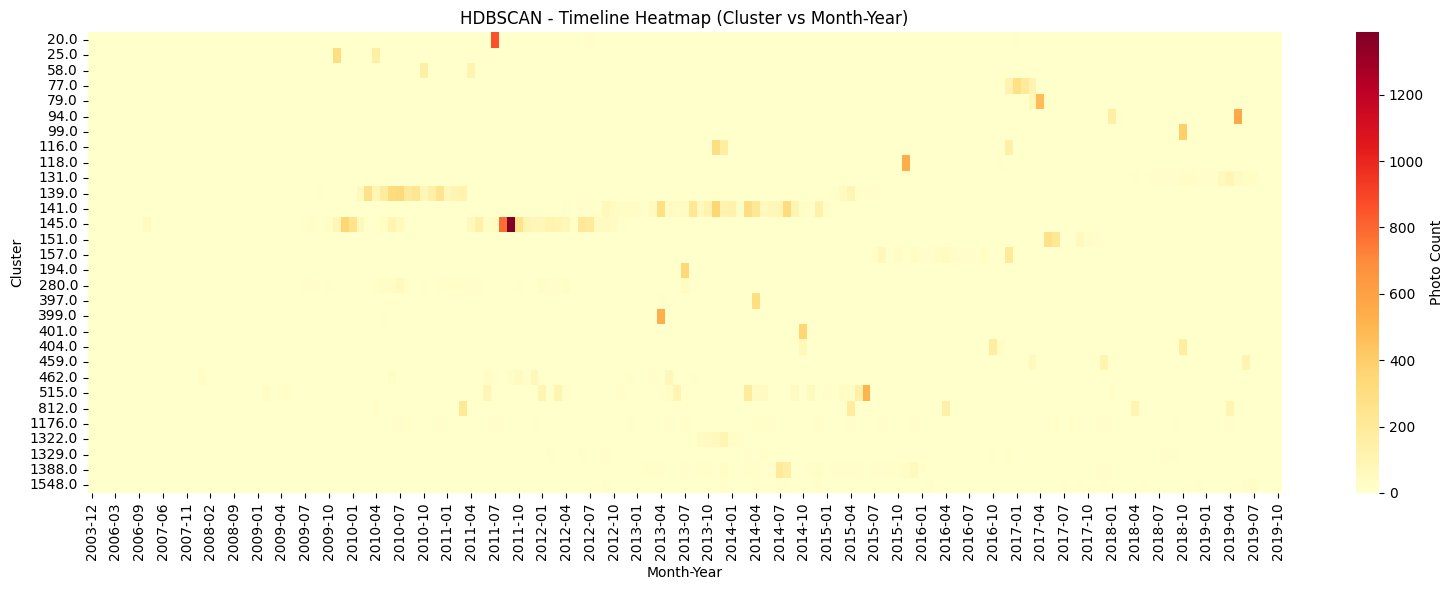

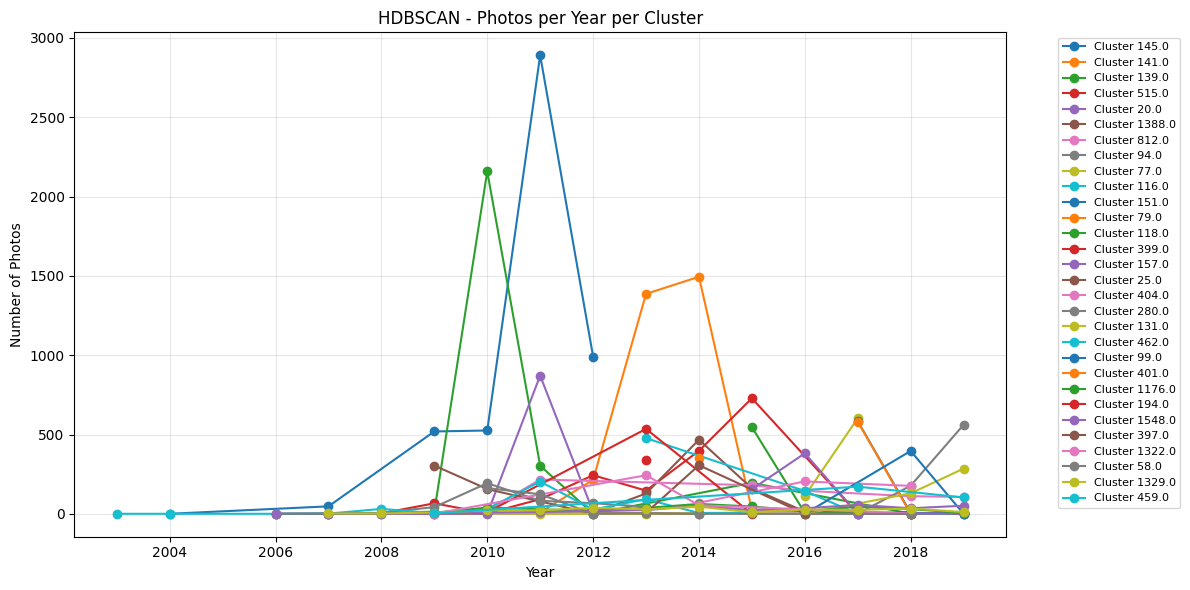

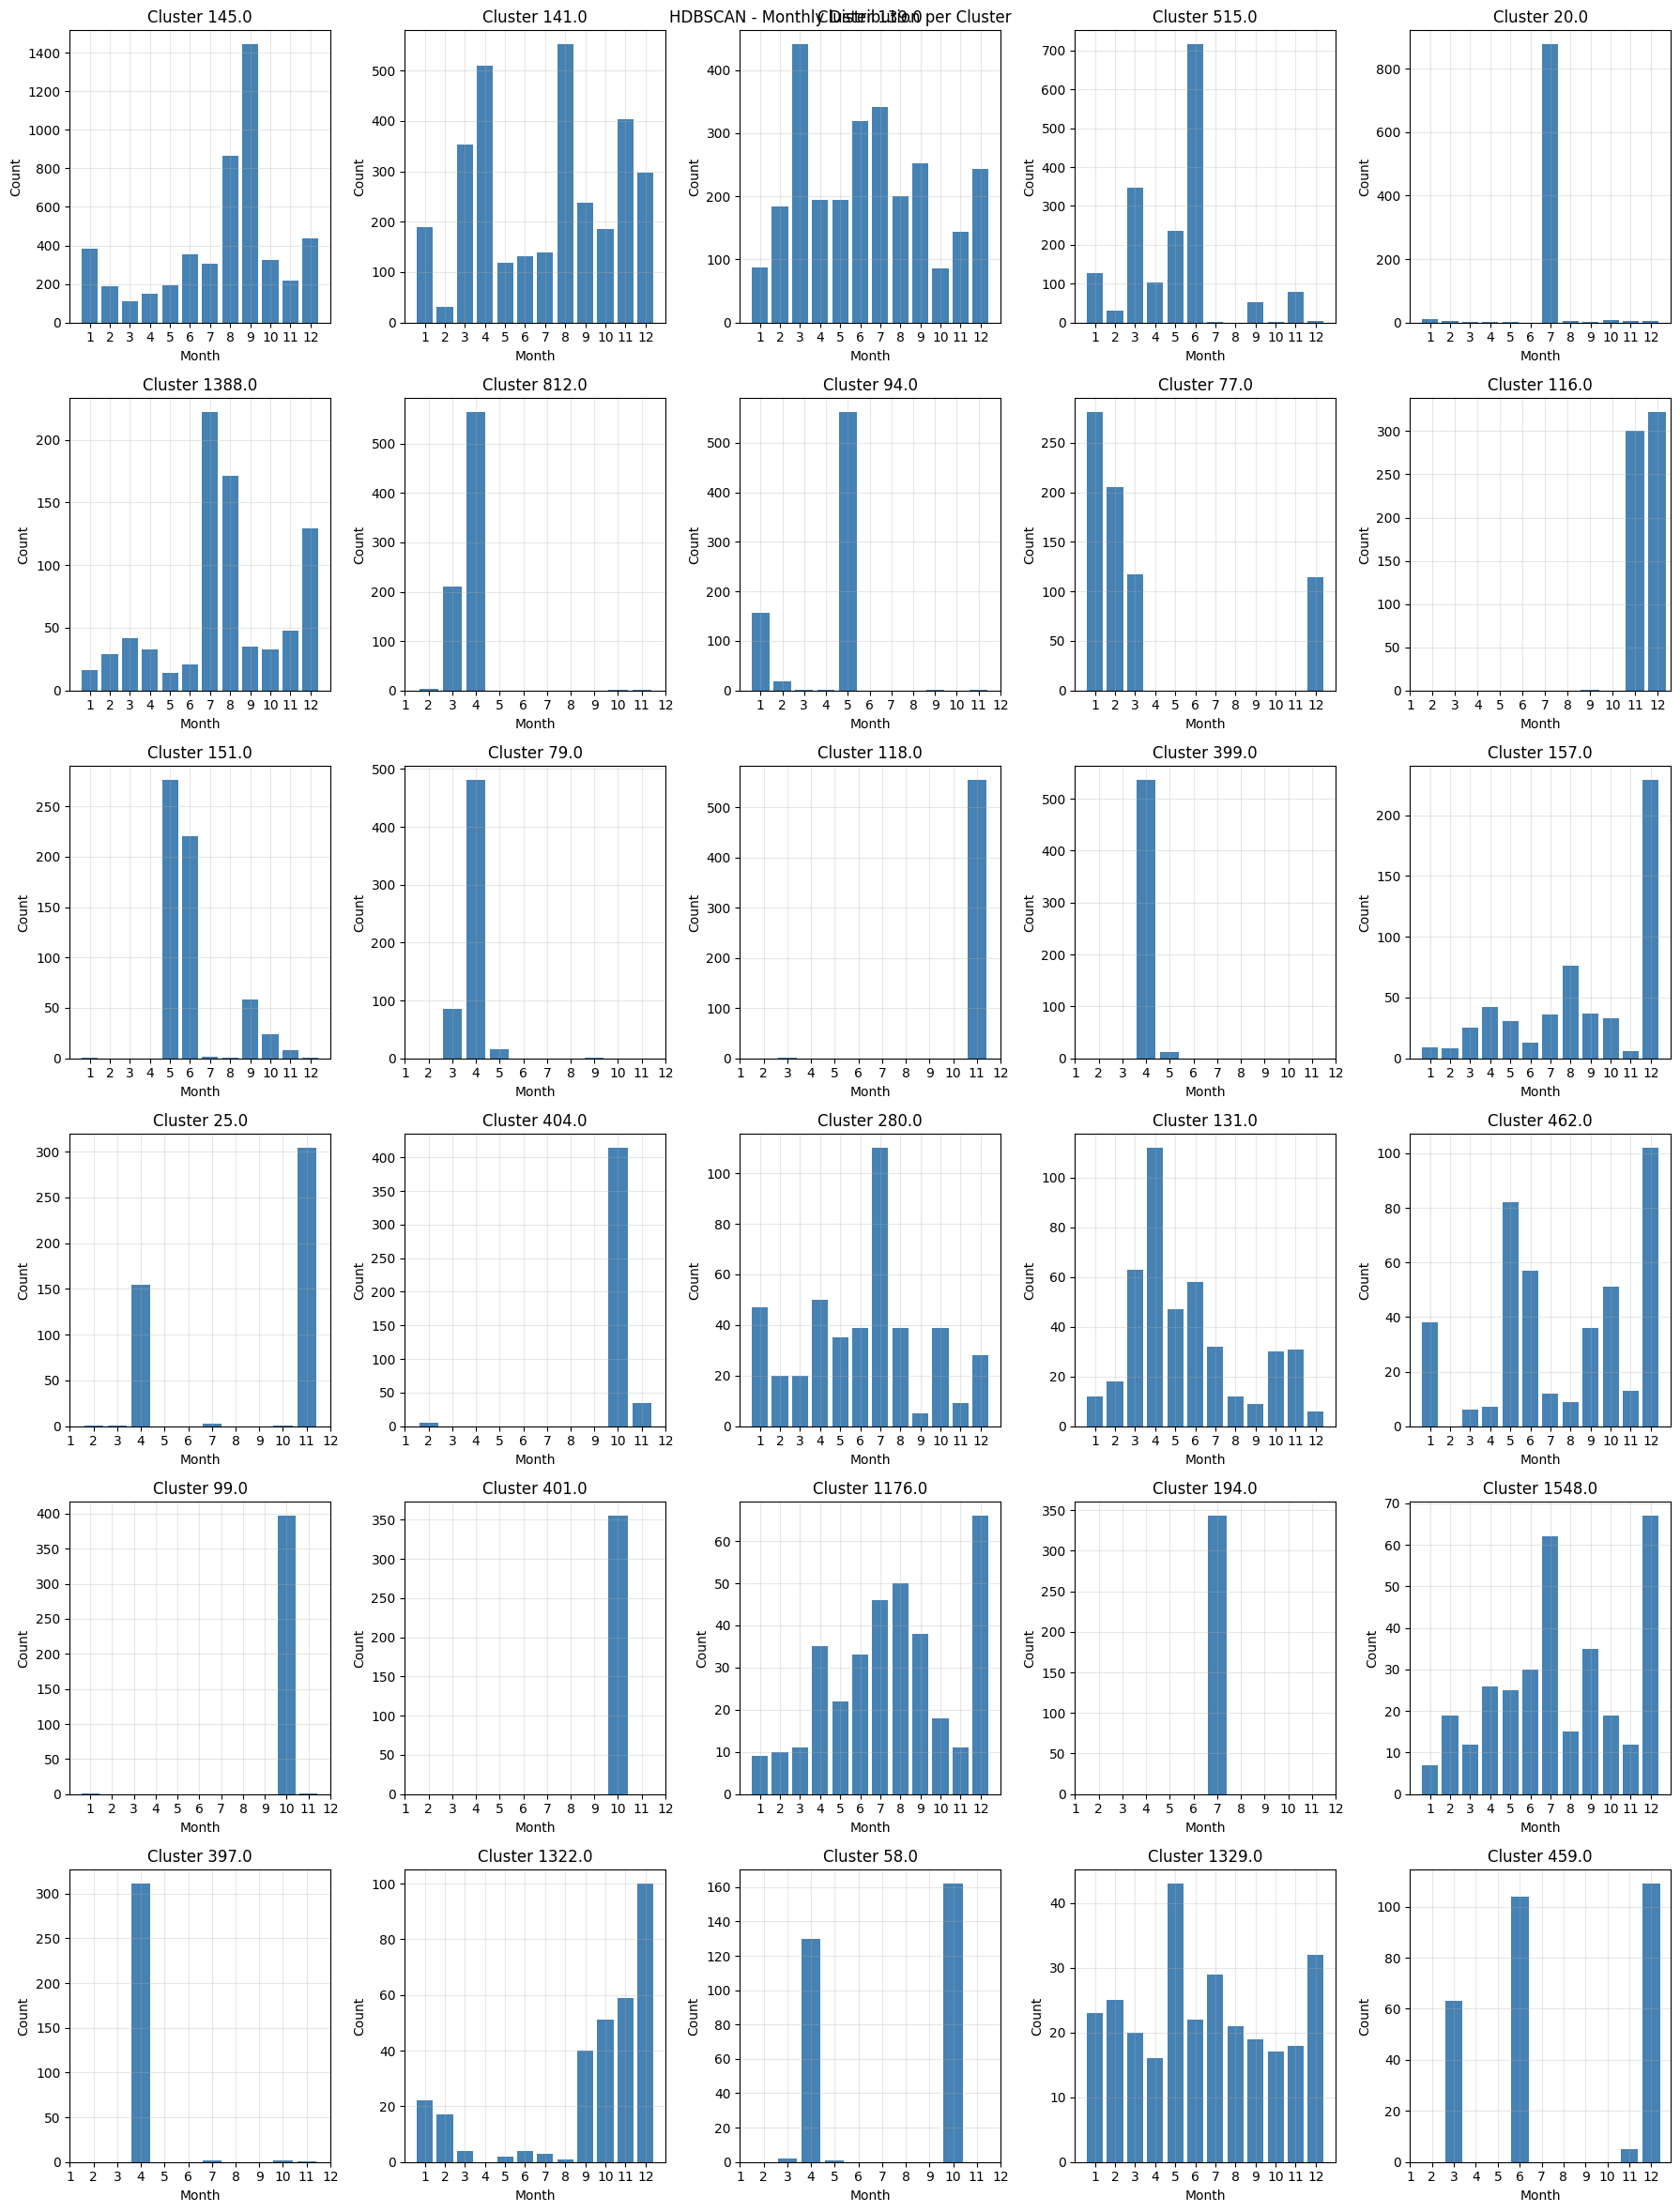

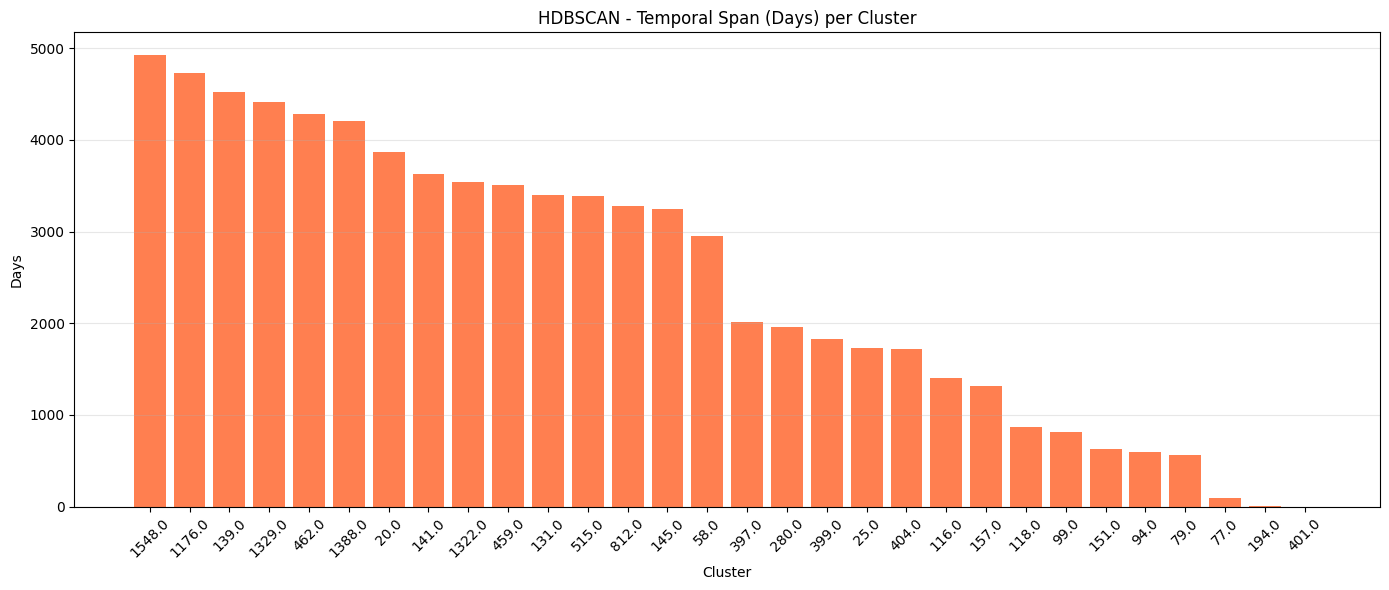


Generating visualizations for DBSCAN...


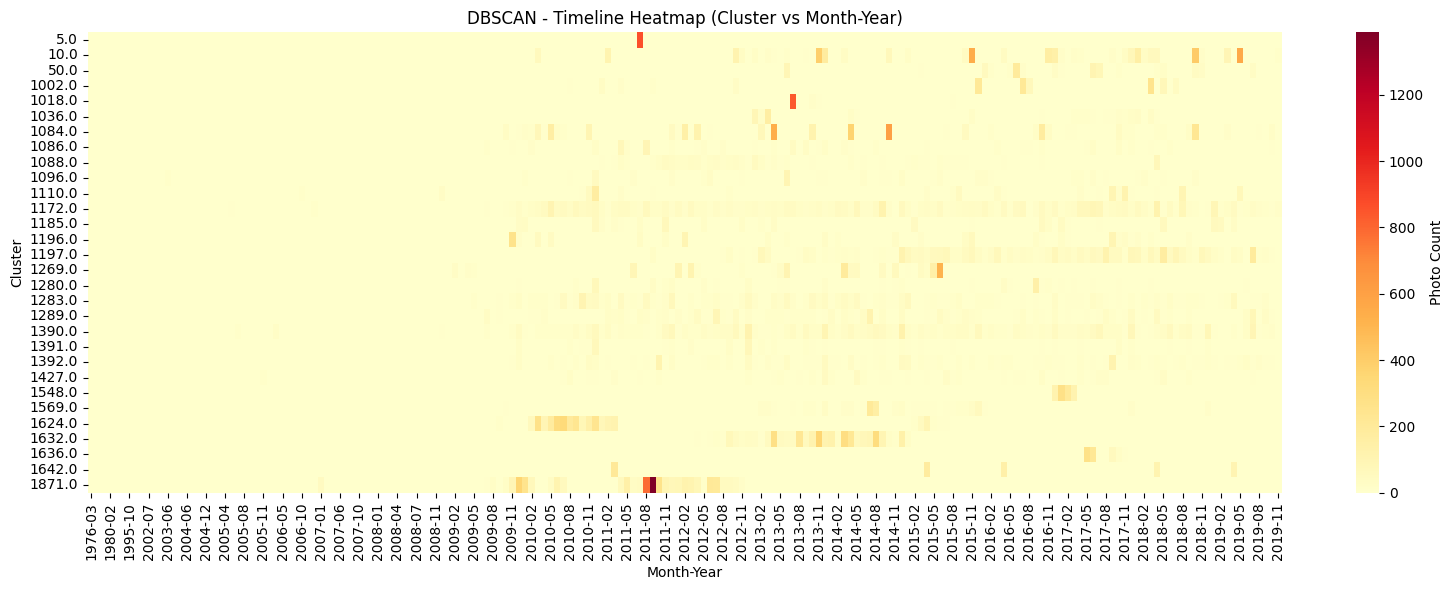

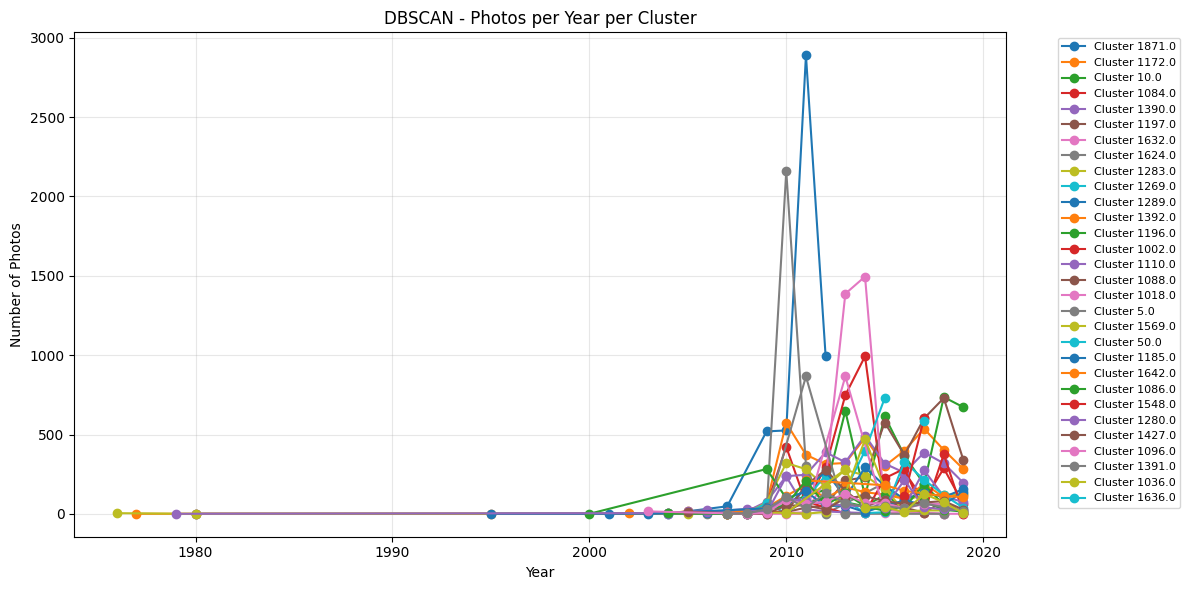

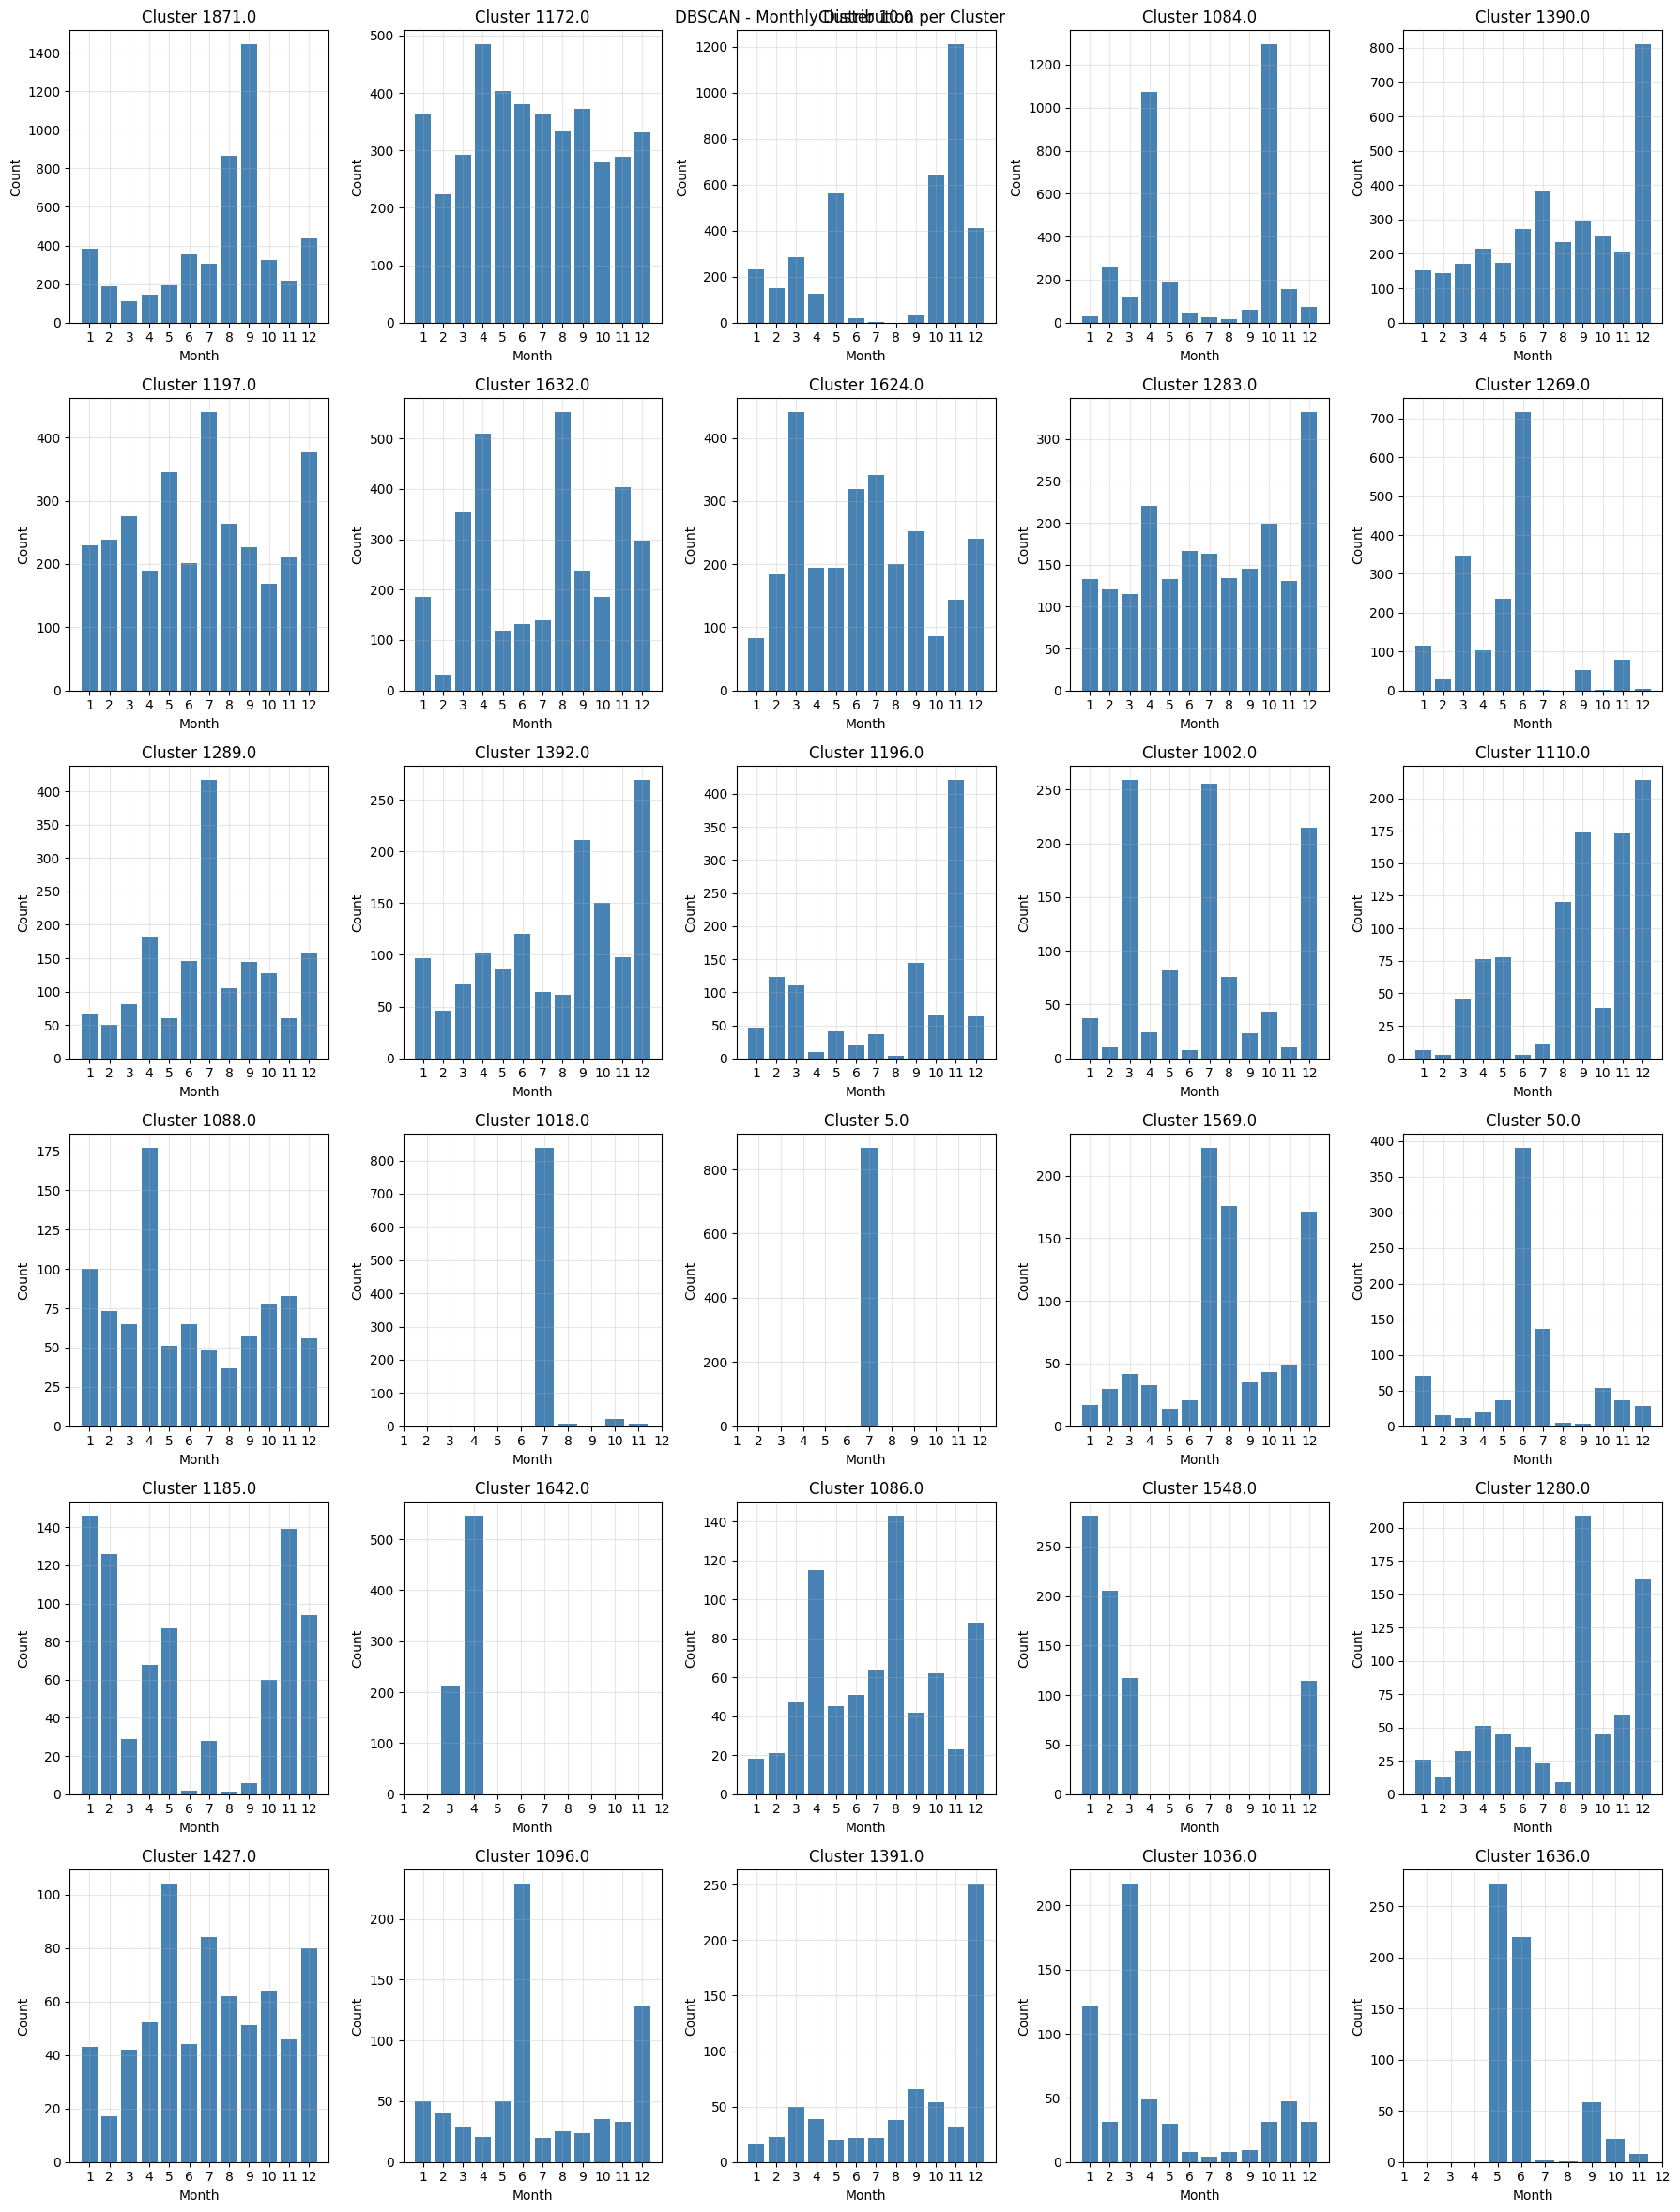

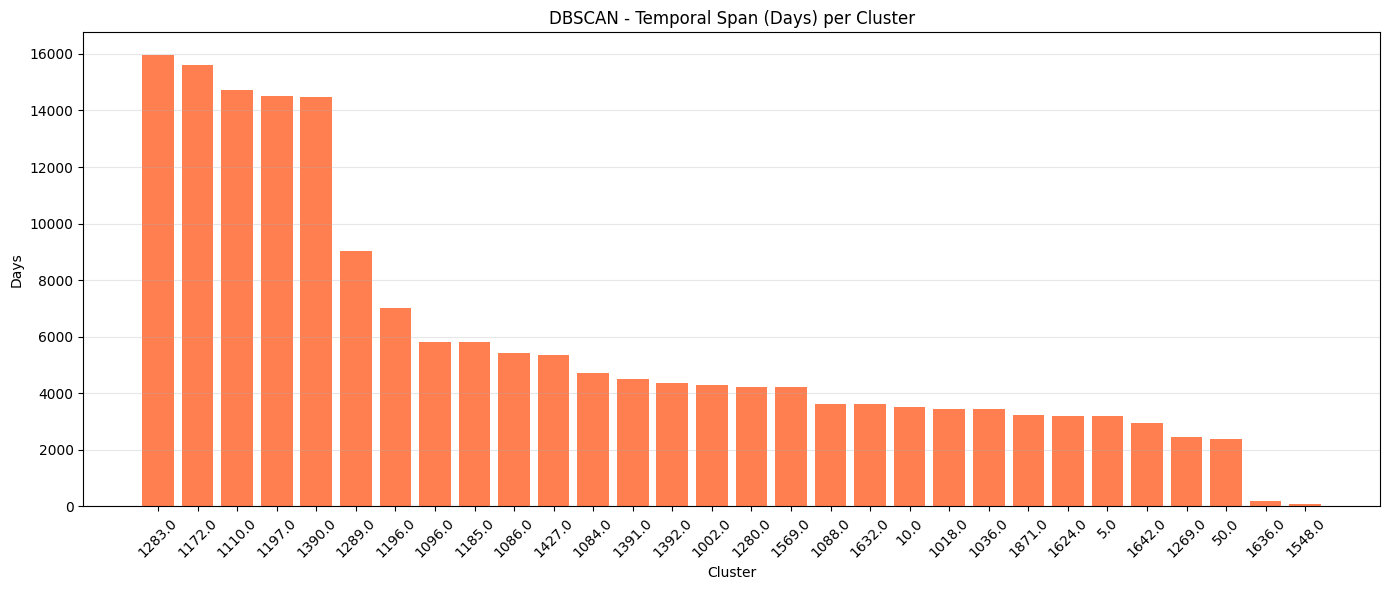


Generating visualizations for KMEAN...


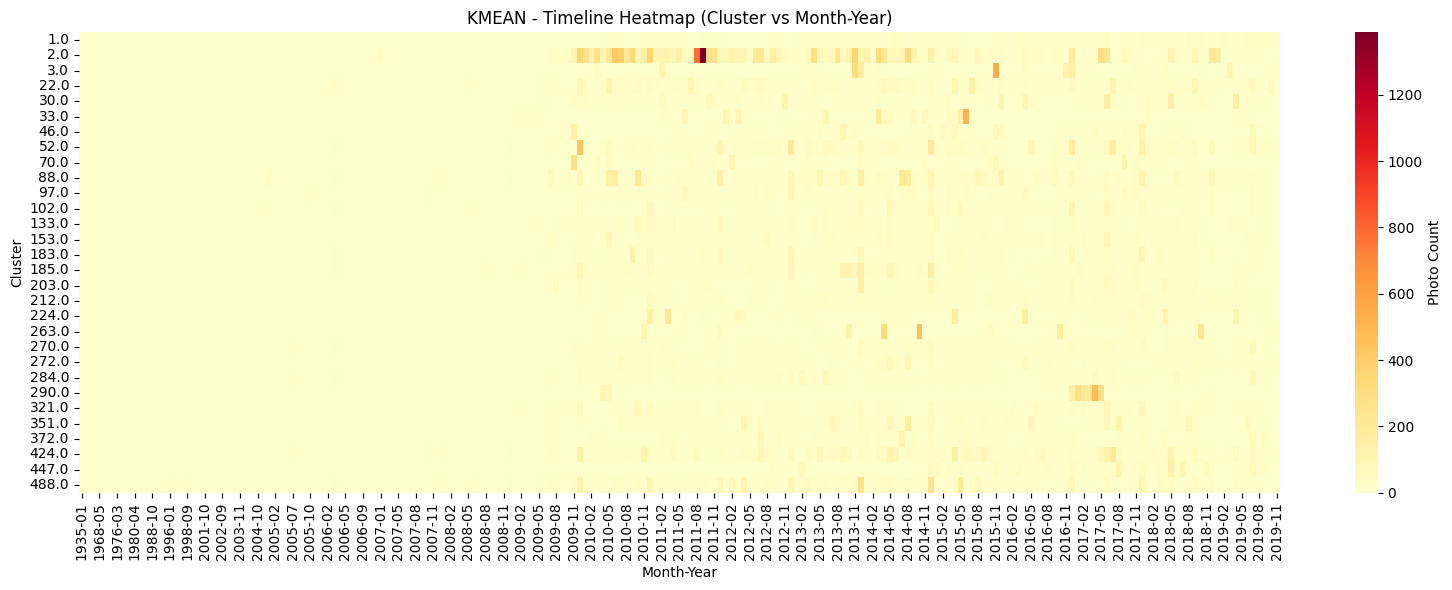

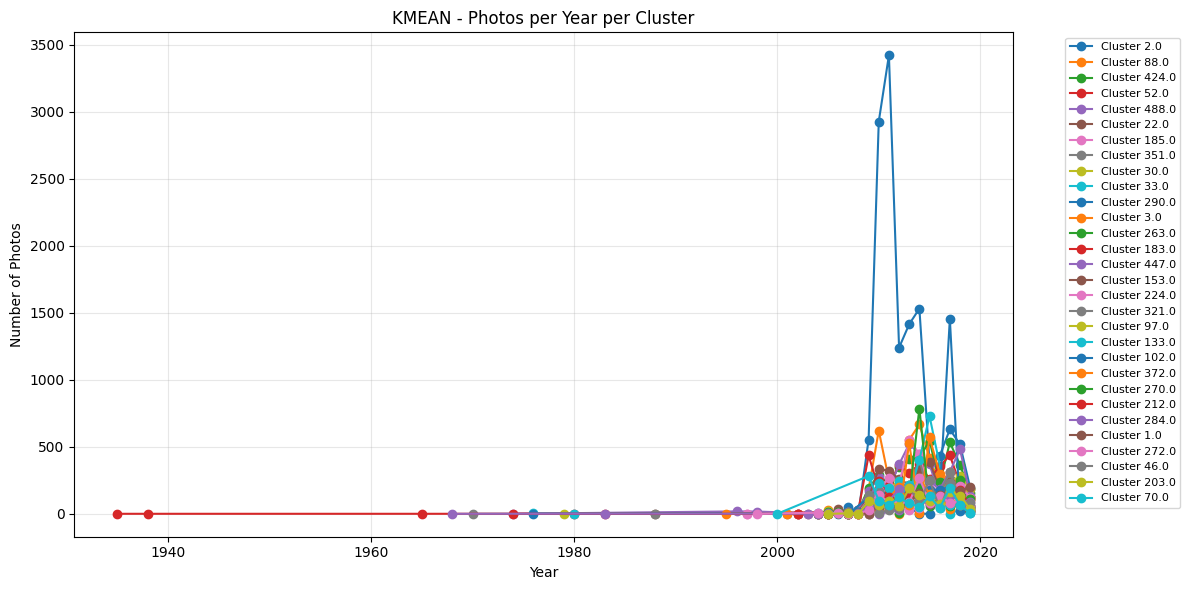

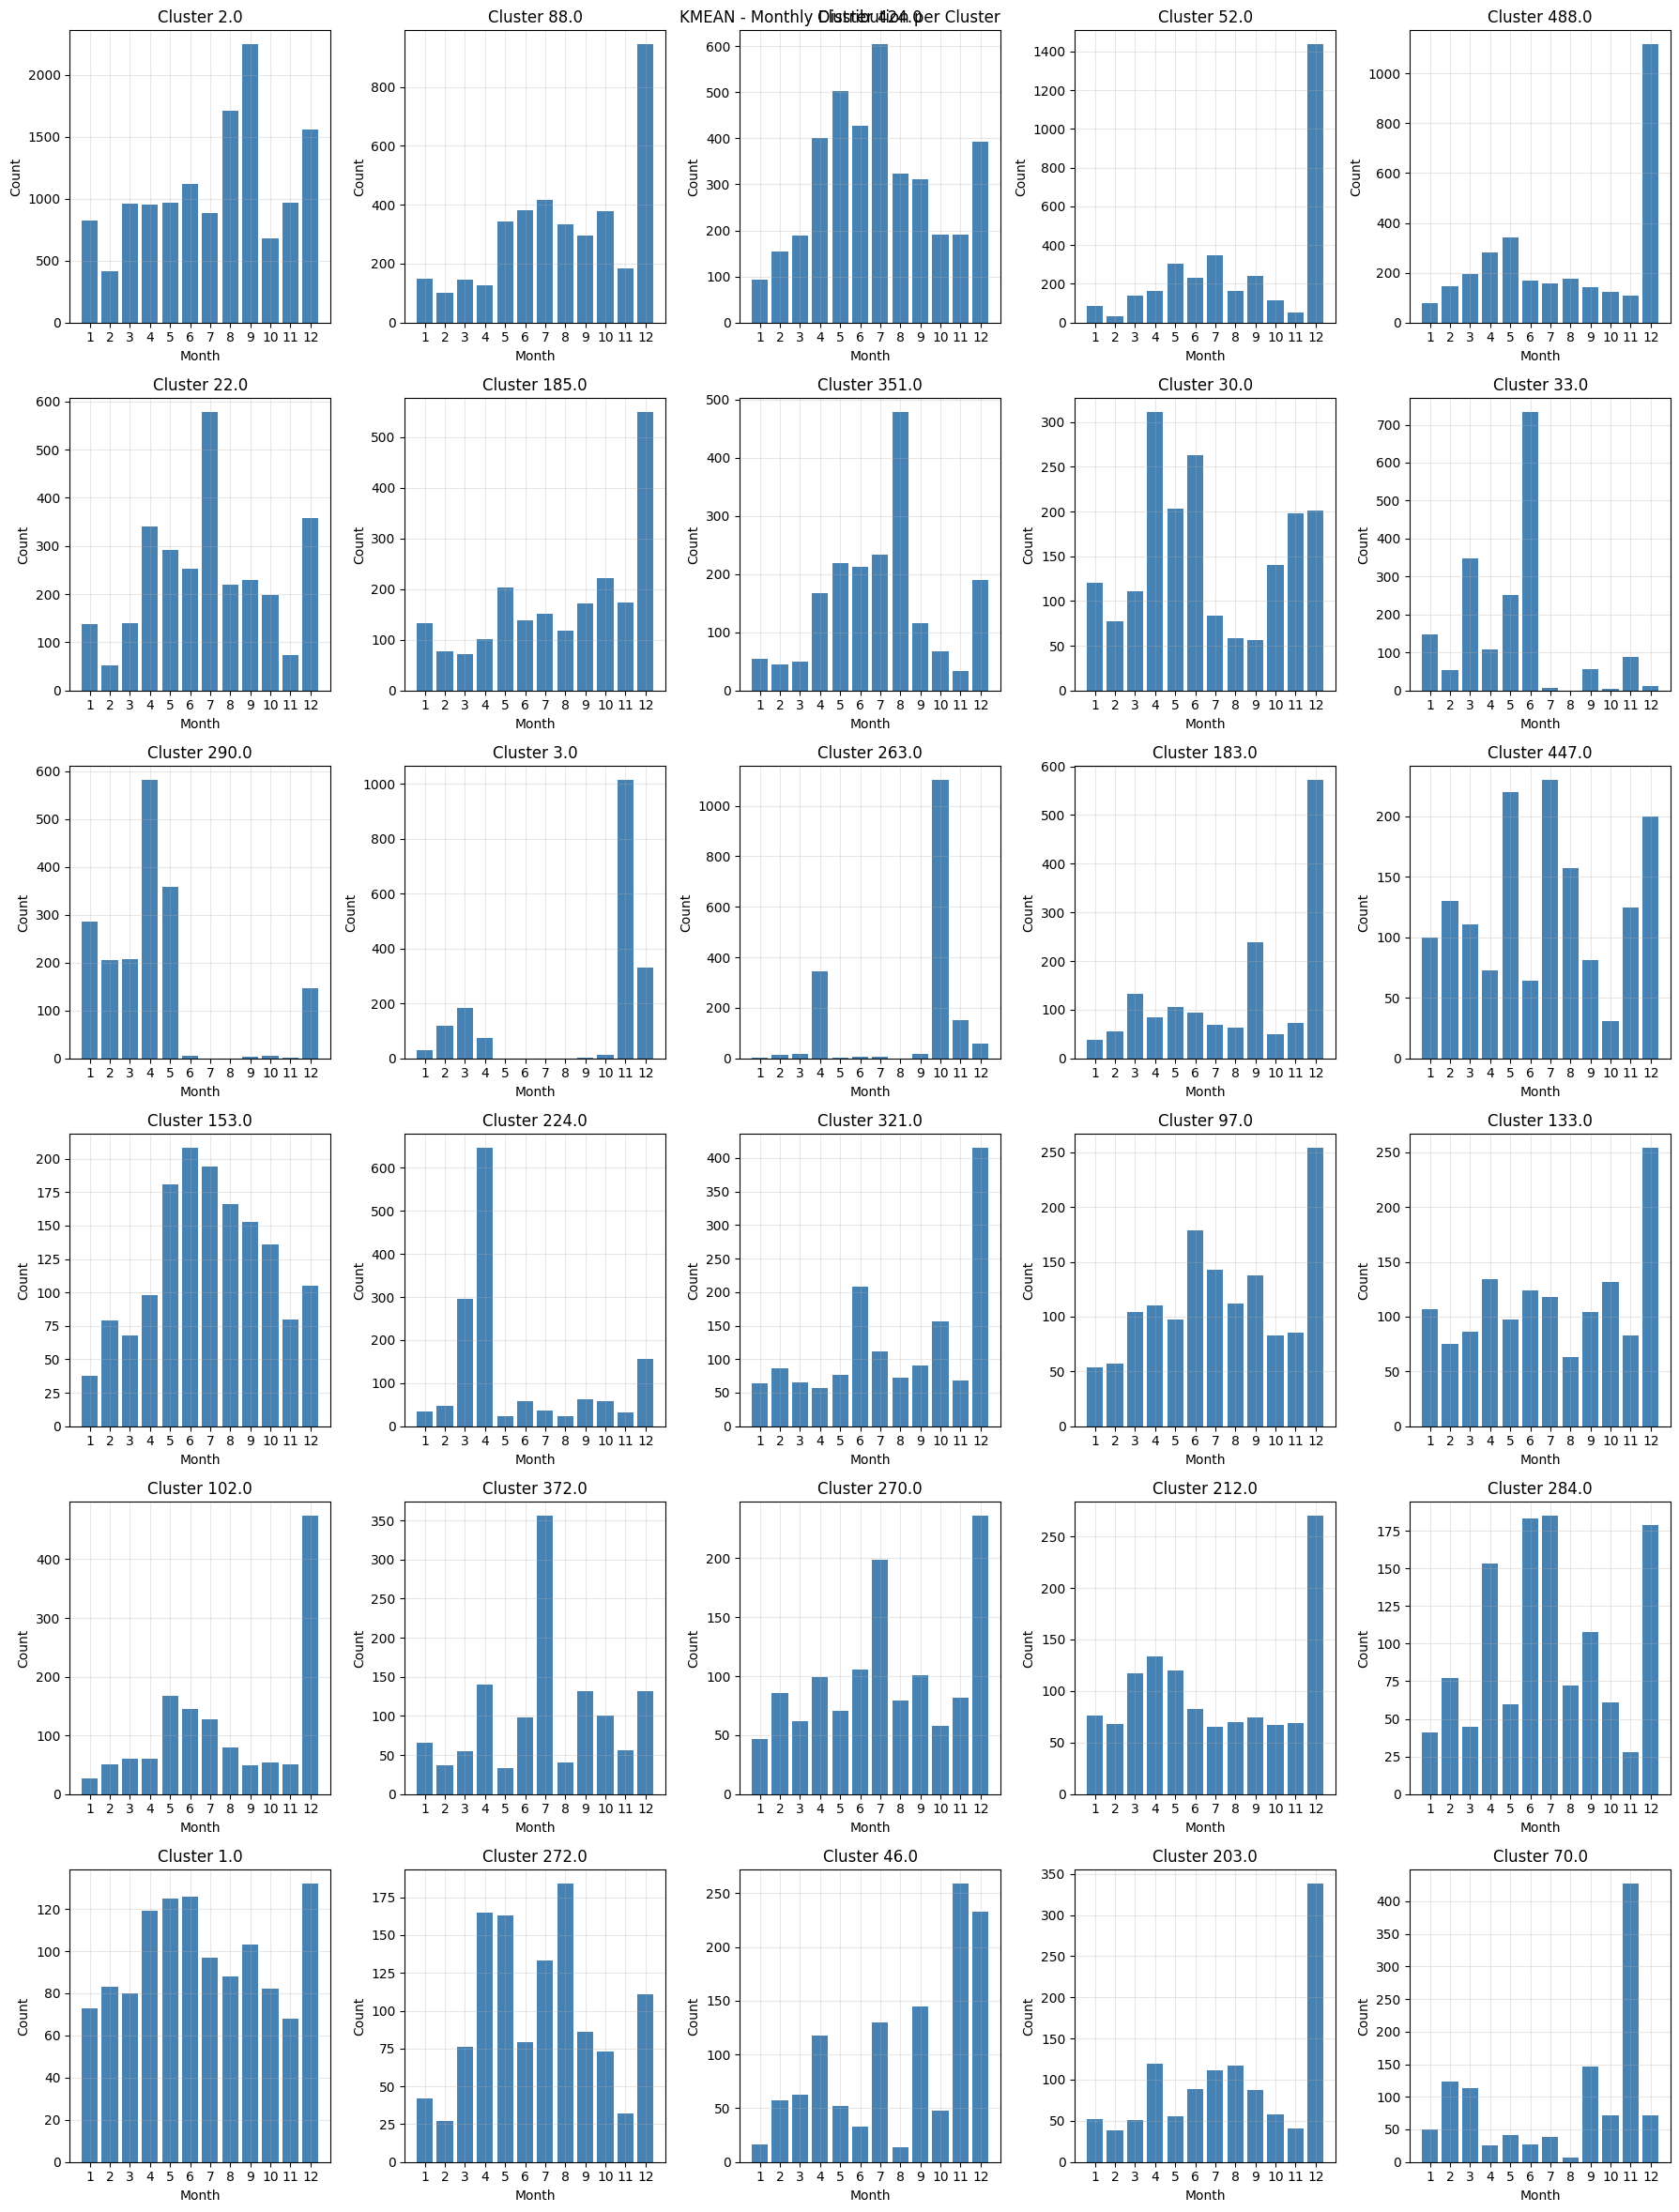

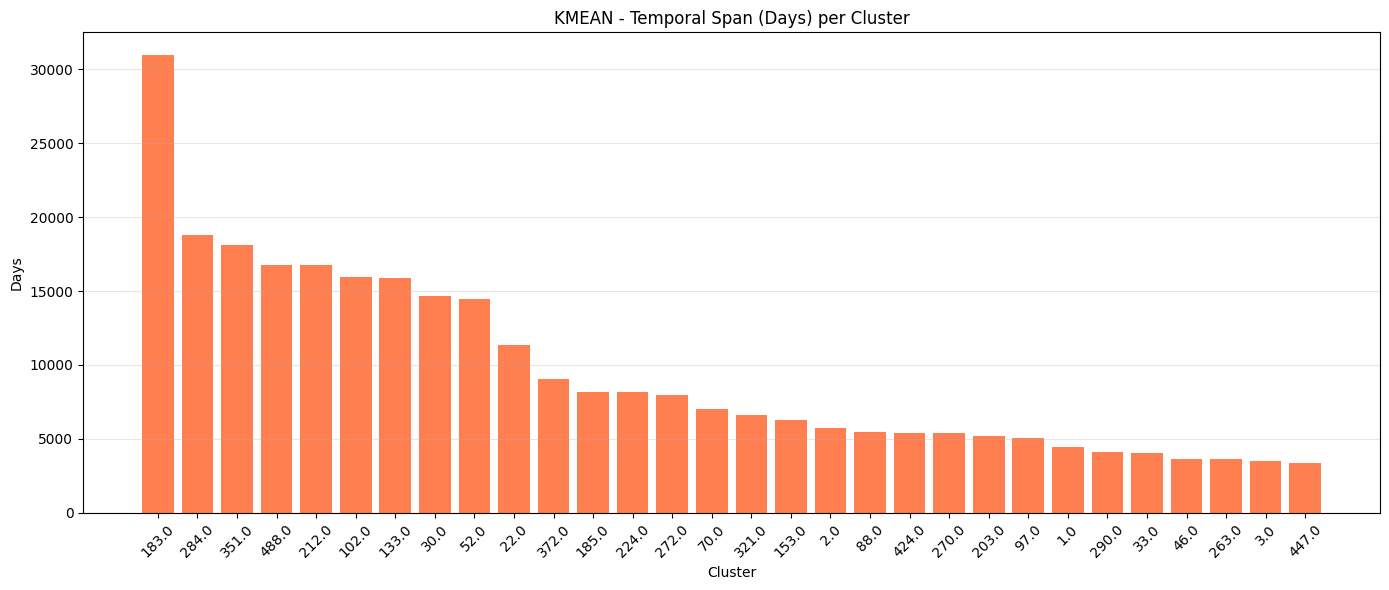


Generating visualizations for ISOLATION_FOREST...

Visualizations complete!


In [3]:

# ===== 4. VISUAL APPROACH - VISUALIZATIONS =====
print("\n\n" + "=" * 80)
print("GENERATING VISUALIZATIONS")
print("=" * 80)

for method in clustering_methods:
    print(f"\nGenerating visualizations for {method.upper()}...")
    
    top_clusters = get_top_clusters(data, method, n_clusters=30)
    
    if not top_clusters:
        continue
    
    # Prepare data for visualization
    cluster_data = data[data[method].isin(top_clusters)].copy()
    cluster_data = cluster_data[cluster_data['date_taken'].notna()]
    
    # 1. Timeline Heatmap: cluster vs year-month with photo counts
    cluster_data['year_month'] = cluster_data['date_taken'].dt.to_period('M')
    heatmap_data = cluster_data.groupby([method, 'year_month']).size().unstack(fill_value=0)
    
    if len(heatmap_data) > 0:
        fig, ax = plt.subplots(figsize=(16, 6))
        sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Photo Count'})
        plt.title(f'{method.upper()} - Timeline Heatmap (Cluster vs Month-Year)')
        plt.xlabel('Month-Year')
        plt.ylabel('Cluster')
        plt.tight_layout()
        plt.show()
    
    # 2. Scatter plot: year vs photo_count per cluster
    yearly_cluster = cluster_data.groupby([method, cluster_data['date_taken'].dt.year]).size().reset_index(name='count')
    yearly_cluster.columns = [method, 'year', 'count']
    
    fig, ax = plt.subplots(figsize=(12, 6))
    for cluster in top_clusters:
        cluster_yearly = yearly_cluster[yearly_cluster[method] == cluster]
        ax.plot(cluster_yearly['year'], cluster_yearly['count'], marker='o', label=f'Cluster {cluster}')
    
    plt.title(f'{method.upper()} - Photos per Year per Cluster')
    plt.xlabel('Year')
    plt.ylabel('Number of Photos')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 3. Month distribution per cluster - with dynamic grid
    n_clusters = len(top_clusters)
    n_cols = 5
    n_rows = (n_clusters + n_cols - 1) // n_cols  # Ceiling division
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
    axes = axes.flatten()  # Flatten to 1D array for easier indexing
    
    for idx, cluster in enumerate(top_clusters):
        cluster_subset = cluster_data[cluster_data[method] == cluster]
        month_counts = cluster_subset['date_taken'].dt.month.value_counts().sort_index()
        
        axes[idx].bar(month_counts.index, month_counts.values, color='steelblue')
        axes[idx].set_title(f'Cluster {cluster}')
        axes[idx].set_xlabel('Month')
        axes[idx].set_ylabel('Count')
        axes[idx].set_xticks(range(1, 13))
        axes[idx].grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(n_clusters, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'{method.upper()} - Monthly Distribution per Cluster')
    plt.tight_layout()
    plt.show()
    
    # 4. Bar plot: temporal span per cluster
    cluster_span_data = []
    for cluster in top_clusters:
        cluster_subset = cluster_data[cluster_data[method] == cluster]
        span = (cluster_subset['date_taken'].max() - cluster_subset['date_taken'].min()).days
        cluster_span_data.append({'cluster': cluster, 'span_days': span})
    
    span_df = pd.DataFrame(cluster_span_data).sort_values('span_days', ascending=False)
    
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.bar(span_df['cluster'].astype(str), span_df['span_days'], color='coral')
    ax.set_title(f'{method.upper()} - Temporal Span (Days) per Cluster')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Days')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

print("\nVisualizations complete!")